In [2]:
from main import *

from itertools import chain, product

import sympy as sp
from sympy import latex
from sympy.abc import c, epsilon, mu, omega, t, x, y, z
from sympy.printing import preview
from sympy.solvers.ode.systems import dsolve_system
from sympy.vector import CoordSys3D, Del
from preview_wrappers import *
#from sympy import *

In [3]:
# setup sympy symbols
R = CoordSys3D("")
delop = Del()  # nabla
phi = sp.Function("phi")
eta = sp.Function("eta")
gamma = sp.Function("gamma")
max_order = 1  # order of expansion
E_symbols, H_symbols, E_vec_comps, H_vec_comps, E_asympt, H_asympt = (
    gen_vector_field_symbols(R, order=max_order)
)

# contsruct Maxwell's equations
eqs_0, alg_eqs_0, diff_eqs_0 = gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=0,
)
eqs_0 = list_subs(
    eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)
alg_eqs_0 = list_subs(
    alg_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)
diff_eqs_0 = list_subs(
    diff_eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x])
)

# solve ODE system
diff_sols_0 = dsolve_system(
    diff_eqs_0,
    funcs=[
        E_symbols[0][1](x),
        E_symbols[0][2](x),
        H_symbols[0][1](x),
        H_symbols[0][2](x),
    ],
    t=x,
)[0]

#assert check_sols(diff_eqs_0, diff_sols_0) == [True, True, True, True]
print("0: Found and checked solution to zero-order method")
assert False
sols_0 = [
    alg_eqs_0[0].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
    diff_sols_0[0],
    diff_sols_0[1],
    alg_eqs_0[1].subs({eq.lhs: eq.rhs for eq in diff_sols_0}),
    diff_sols_0[2],
    diff_sols_0[3],
]

sols_0 = list_subs(
    sols_0,
    {
        omega / c * sp.sqrt(-epsilon * mu + sp.diff(phi(z), z) ** 2): gamma(z),
        -epsilon * mu + sp.diff(phi(z), z) ** 2: eta(z),
    },
    eval=False,
)

# remove denominator to shorten expressions
sols_0 = list_subs(
    sols_0,
    {
        sp.Symbol("C1"): sp.Symbol("C1") * sp.sqrt(eta(z)),
        sp.Symbol("C2"): sp.Symbol("C2") * sp.sqrt(eta(z)),
        sp.Symbol("C3"): sp.Symbol("C3") * epsilon,
        sp.Symbol("C4"): sp.Symbol("C4") * epsilon,
    },
    eval=False,
)

save_latex_as_image(sols_0, "general_solution_zero_order")

# Construct solutions for different layers
sols_0_layers = {
    layer: layered_sols(sols_0, layer, order=0) for layer in ["c", "f", "s"]
}

# Now solving for 2D waveguide with smoothly irregular transition, x=h(z)

# boundry conditions
h = sp.Function("h")
border_func = R.x - h(R.z)

E_boundry_cf_0 = gen_boundry_conds(
    R, delop, E_vec_comps[0], border_func, h(z), ["c", "f"], order=0
)

H_boundry_cf_0 = gen_boundry_conds(
    R, delop, H_vec_comps[0], border_func, h(z), ["c", "f"], order=0
)

E_boundry_fs_0 = gen_boundry_conds(
    R, delop, E_vec_comps[0], border_func, 0, ["f", "s"], order=0
)

H_boundry_fs_0 = gen_boundry_conds(
    R, delop, H_vec_comps[0], border_func, 0, ["f", "s"], order=0
)

boundry_eqs_0 = list_subs(
    E_boundry_cf_0 + H_boundry_cf_0 + E_boundry_fs_0 + H_boundry_fs_0,
    {
        eq.lhs: eq.rhs
        for eq in list_subs(
            sols_0_layers["c"] + sols_0_layers["f"], {x: h(z)}, eval=False
        )
        + list_subs(sols_0_layers["f"] + sols_0_layers["s"], {x: 0}, eval=False)
    },
    eval=False,
)

# order is intentional to produce block-diagonal matrix
sym_coeffs_0 = [
    # TE
    sp.Symbol("A_0^c"),
    sp.Symbol("A_0^f"),
    sp.Symbol("B_0^f"),
    sp.Symbol("A_0^s"),
    # TM
    sp.Symbol("B_0^c"),
    sp.Symbol("C_0^f"),
    sp.Symbol("D_0^f"),
    sp.Symbol("B_0^s"),
]

# reorder equations to block-diagonal matrix of coefficients
new_ord = [1, 2, 5, 6, 0, 3, 4, 7]
boundry_eqs_0 = [boundry_eqs_0[i] for i in new_ord]
M_0, _ = sp.linear_eq_to_matrix(boundry_eqs_0, sym_coeffs_0)

M_0_TE = M_0[:4, :4]
sym_coeffs_0_TE = sym_coeffs_0[:4]

eqs_0_TE = [
    sp.Eq(eq.collect(sym_coeffs_0_TE, sp.combsimp), 0)
    for eq in M_0_TE * sp.matrices.Matrix(sym_coeffs_0_TE)
]

sol_coeffs_0_TE = solve_all(eqs_0_TE, sym_coeffs_0_TE)

sol_coeffs_0_TE = [
    {
        coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.simplify)
        for coeff, expr in sol.items()
    }
    for sol in sol_coeffs_0_TE
]
print(f"0: found coefficients for TE-mode:{sym_coeffs_0_TE}")
# save_latex_as_image(sol_coeffs_0_TE, "coeffs_0_TE_all")

# boundry_check_all_solutions(eqs_0_TE, sym_coeffs_0_TE, sol_coeffs_0_TE)
# print("0: check all variants of the solutions to boundry equations TE mode")

M_0_TM = M_0[4:, 4:]
sym_coeffs_0_TM = sym_coeffs_0[4:]
eqs_0_TM = [
    sp.Eq(eq.collect(sym_coeffs_0_TM, sp.combsimp), 0)
    for eq in M_0_TM * sp.matrices.Matrix(sym_coeffs_0_TM)
]

sol_coeffs_0_TM = solve_all(eqs_0_TM, sym_coeffs_0_TM)

sol_coeffs_0_TM = [
    {
        coeff: expr.expand().collect(sp.exp(sp.Wild("w")), sp.combsimp)
        for coeff, expr in sol.items()
    }
    for sol in sol_coeffs_0_TM
]

print(f"0: found coefficients for TM-mode:{sym_coeffs_0_TM}")

# NOTE: unable to finish with default algortims. Manually checked for 3rd
# and 4th sets.
# boundry_check_all_solutions(eqs_0_TM, sym_coeffs_0_TM, sol_coeffs_0_TM)
# print("0: check all variants of the solutions to boundry equations TM mode")

# save_latex_as_image(sol_coeffs_0_TM, "coeffs_0_TM_all")

# TODO: check if expressions found are indeed solutions to the system
# after substitution one of four equations has to contain Det(M),
# which has to be zero for non-trivial solution to exist

eqs_1, alg_eqs_1, diff_eqs_1 = gen_maxwell_eqs(
    R,
    delop,
    phi,
    E_symbols,
    H_symbols,
    E_vec_comps,
    H_vec_comps,
    E_asympt,
    H_asympt,
    order=1,
    prev_order_eqs=list_subs(
        eqs_0, gen_vars_subs([E_symbols[0], H_symbols[0]], [x], [x, y, z])
    ),
)

# derivs_subs = {
#     sp.Derivative(E_symbols[0][0](x, z), z): sp.Function("S_1")(x, z),
#     sp.Derivative(H_symbols[0][1](x, z), z): sp.Function("S_2")(x, z),
#     sp.Derivative(H_symbols[0][0](x, z), z): sp.Function("S_3")(x, z),
#     sp.Derivative(E_symbols[0][1](x, z), z): sp.Function("S_4")(x, z),
# }

eqs_1 = list_subs(
    eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)
alg_eqs_1 = list_subs(
    alg_eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)
diff_eqs_1 = list_subs(
    diff_eqs_1,
    gen_vars_subs([E_symbols[1], H_symbols[1]], [x, y, z], [x])
    | gen_vars_subs([E_symbols[0], H_symbols[0]], [x, y, z], [x, z]),
    # | derivs_subs,
)

# save_latex_as_image(diff_eqs_1, "diff_eqs_1")

diff_sols_1 = dsolve_system(
    # list_subs(diff_eqs_1, derivs_subs),
    diff_eqs_1,
    funcs=[
        E_symbols[1][1](x),
        E_symbols[1][2](x),
        H_symbols[1][1](x),
        H_symbols[1][2](x),
    ],
    t=x,
)[0]

print("1: Found solution to ODE system")

# NOTE: A *LOT* of compute time to check
assert check_sols(diff_eqs_1, diff_sols_1) == [True, True, True, True]
print("1: checked if the solution is correct")

sols_1 = [
    alg_eqs_1[0].subs({eq.lhs: eq.rhs for eq in diff_sols_1}),
    diff_sols_1[0],
    diff_sols_1[1],
    alg_eqs_1[1].subs({eq.lhs: eq.rhs for eq in diff_sols_1}),
    diff_sols_1[2],
    diff_sols_1[3],
]

gamma_1 = sp.Function("gammatilde")  # in first order gamma is different from zeroth
sols_1 = list_subs(
    sols_1,
    {
        omega / c * sp.sqrt(-epsilon * mu + sp.diff(phi(z), z) ** 2): gamma_1(z),
        -epsilon * mu + sp.diff(phi(z), z) ** 2: eta(z),
    },
    eval=False,
)

sols_1 = [
    eq.replace(sp.Integral, lambda *args: sp.simplify(sp.Integral(*args)))
    for eq in sols_1
]
save_latex_as_image(sols_1, "solution_1st_order")

# sub particular part of the ode soluiton to avoid dealing with integrals
U_p_symbols = [
    sp.Function(f"{U}^{{{i}}}_p")(x, z) for U, i in product(["E", "H"], [x, y, z])
]
sols_1_particular_part = {
    sol.rhs.expand()
    - sum(
        filter(lambda e: e.has(*sp.symbols("C1 C2 C3 C4")), sol.rhs.expand().args)
    ): U_p_symbols[i]
    for i, sol in enumerate(sols_1)
}
sols_1_with_p = [sol.expand().subs(sols_1_particular_part) for sol in sols_1]

# Construct solutions for different layers
sols_1_layers = {
    layer: layered_sols(sols_1_with_p, layer, order=1) for layer in ["c", "f", "s"]
}

save_latex_as_image(sols_1_layers["c"], "sols_1_cover")
save_latex_as_image(sols_1_layers["f"], "sols_1_film")
save_latex_as_image(sols_1_layers["s"], "sols_1_substrate")

print("1: reconstructed ODE solution to hide particular part")

# Now solving for 2D waveguide with smoothly irregular transition, x=h(z)

# boundry conditions
h = sp.Function("h")
border_func = R.x - h(R.z)

E_boundry_cf_1 = gen_boundry_conds(
    R, delop, E_vec_comps[1], border_func, h(z), ["c", "f"], order=1
)

H_boundry_cf_1 = gen_boundry_conds(
    R, delop, H_vec_comps[1], border_func, h(z), ["c", "f"], order=1
)

E_boundry_fs_1 = gen_boundry_conds(
    R, delop, E_vec_comps[1], border_func, 0, ["f", "s"], order=1
)

H_boundry_fs_1 = gen_boundry_conds(
    R, delop, H_vec_comps[1], border_func, 0, ["f", "s"], order=1
)

boundry_eqs_1 = list_subs(
    E_boundry_cf_1 + H_boundry_cf_1 + E_boundry_fs_1 + H_boundry_fs_1,
    {
        eq.lhs: eq.rhs
        for eq in list_subs(
            sols_1_layers["c"] + sols_1_layers["f"], {x: h(z)}, eval=False
        )
        + list_subs(sols_1_layers["f"] + sols_1_layers["s"], {x: 0}, eval=False)
    },
    eval=False,
)
print("1: construct boundry conditions in general form")

# order is intentional to produce block-diagonal matrix
sym_coeffs_1 = [
    # TE
    sp.Symbol("A_1^c"),
    sp.Symbol("A_1^f"),
    sp.Symbol("B_1^f"),
    sp.Symbol("A_1^s"),
    # TM
    sp.Symbol("B_1^c"),
    sp.Symbol("C_1^f"),
    sp.Symbol("D_1^f"),
    sp.Symbol("B_1^s"),
]

# reorder equations to block-diagonal matrix of coefficients
new_ord = [1, 2, 5, 6, 0, 3, 4, 7]
boundry_eqs_1 = [boundry_eqs_1[i] for i in new_ord]
M_1, _ = sp.linear_eq_to_matrix(boundry_eqs_1, sym_coeffs_1)

# preview(
#     (M_1, b),
#     output="png",
#     dvioptions=["-D 200"],
#     euler=False,
# )

M_1_TE = M_1[:4, :4]
sym_coeffs_1_TE = sym_coeffs_1[:4]

q_TE = sp.Matrix([sp.Symbol(f"q_{i}") for i in range(1, 5)])
d_q_TE = q_TE.to_DM()

d_M_1_TE = M_1_TE.to_DM()

sol_coeffs_1_TE, det_1_TE = d_M_1_TE.solve_den_charpoly(d_q_TE)
sol_coeffs_1_TE = sol_coeffs_1_TE.to_Matrix()
sol_coeffs_1_TE = sp.Matrix(
    [sol_coeffs_1_TE[i].expand().combsimp() for i in range(4)]
)
det_1_TE = det_1_TE.expand().combsimp()

assert sp.expand((d_M_1_TE * sol_coeffs_1_TE.to_DM()).to_Matrix()) - sp.expand(
    sp.Matrix([det_1_TE * i for i in q_TE])
)
print(f"1: found and checked coefficients TE-mode:{sym_coeffs_1_TE}")

save_latex_as_image(det_1_TE, "determinant_1_TE")
save_latex_as_image(sol_coeffs_1_TE, "coeffs_1_TE")

M_1_TM = M_1[4:, 4:]
sym_coeffs_1_TM = sym_coeffs_1[4:]
d_M_1_TM = M_1_TM.to_DM()

q_TM = sp.Matrix([sp.Symbol(f"q_{i}") for i in range(5, 9)])
d_q_TM = q_TM.to_DM()

d_M_1_TM = M_1_TM.to_DM()

sol_coeffs_1_TM, det_1_TM = d_M_1_TM.solve_den_charpoly(d_q_TM)
sol_coeffs_1_TM = sol_coeffs_1_TM.to_Matrix()
sol_coeffs_1_TM = sp.Matrix(
    [sol_coeffs_1_TM[i].expand().combsimp() for i in range(4)]
)

det_1_TM = det_1_TM.expand().combsimp()
assert sp.expand((d_M_1_TM * sol_coeffs_1_TM.to_DM()).to_Matrix()) - sp.expand(
    sp.Matrix([det_1_TM * i for i in q_TM])
)

print(f"1: found and checked coefficients TM-mode:{sym_coeffs_1_TM}")

save_latex_as_image(det_1_TM, "determinant_1_TM")
save_latex_as_image(sol_coeffs_1_TM, "coeffs_1_TM")


0: Found and checked solution to zero-order method


AssertionError: 

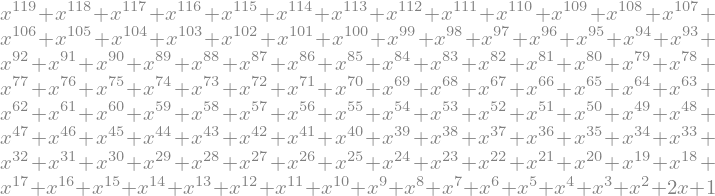

In [8]:
from IPython.display import display, Math, Latex
from IPython.core.display import display_html
from sympy import *
init_session(quiet=True)
init_printing()
x = symbols('x')
arg = x
for i in range(120):
    arg += x**i
arg


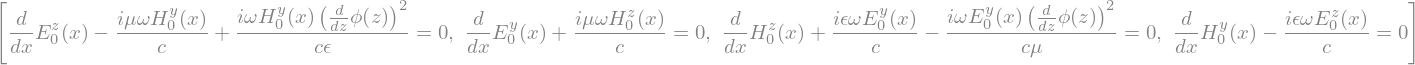

In [10]:
sp.init_printing(wrap_line=True, num_columns=0)
diff_eqs_0

In [6]:
waveguide_params = {sp.Symbol(f"mu_{i}"):1 for i in ["c", "f", "s"]}
waveguide_params[sp.Symbol("epsilon_c")] = sp.Rational('1.0')
waveguide_params[sp.Symbol("epsilon_f")] = sp.Rational('1.565')**2
waveguide_params[sp.Symbol("epsilon_s")] = sp.Rational('1.47')**2

waveguide_params[sp.Symbol("h1")] = 2*sp.Rational('0.55')
waveguide_params[sp.Symbol("h1")] = 2*sp.Rational('0.55')
waveguide_params[sp.Symbol("L")] = 100*sp.Rational('0.55')

In [8]:
E_vec_comps[1]

(E^x_1(.x, .y, .z))*.i + (E^y_1(.x, .y, .z))*.j + (E^z_1(.x, .y, .z))*.k

In [143]:
delop.dot(E_asympt[0]*sp.exp(sp.I * omega * (t - phi(R.z)/c))) \
.doit().powsimp() \
.subs({sp.exp(sp.I * omega * (t - phi(R.z)/c)):1}|gen_subs_diff(R, E_vec_comps[0])) \
.subs({R.x: x, R.y: y, R.z: z}).combsimp().subs({E_symbols[0][0](x,y,z):alg_eqs_0[0].rhs}).doit().expand()

Derivative(H^y_0(x), x)*Derivative(phi(z), z)/epsilon - I*omega*E^z_0(x, y, z)*Derivative(phi(z), z)/c

In [95]:
sp.combsimp(diff_eqs_0[1])

Eq((c*Derivative(E^y_0(x), x) + I*mu*omega*H^z_0(x))/c, 0)

In [125]:
delop.dot(E_asympt[0]*sp.exp(sp.I * omega * (t - phi(R.z)/c))).doit()

exp(I*omega*(t - phi(.z)/c))*Derivative(E^x_0(.x, .y, .z), .x) + exp(I*omega*(t - phi(.z)/c))*Derivative(E^y_0(.x, .y, .z), .y) + exp(I*omega*(t - phi(.z)/c))*Derivative(E^z_0(.x, .y, .z), .z) - I*omega*E^z_0(.x, .y, .z)*exp(I*omega*(t - phi(.z)/c))*Derivative(phi(.z), .z)/c

In [132]:
delop.dot(E_asympt[1]*sp.exp(sp.I * omega * (t - phi(R.z)/c))).doit().subs({sp.exp(sp.I * omega * (t - phi(R.z)/c)):1}).expand()

Derivative(E^x_0(.x, .y, .z), .x) + Derivative(E^y_0(.x, .y, .z), .y) + Derivative(E^z_0(.x, .y, .z), .z) - I*Derivative(E^x_1(.x, .y, .z), .x)/omega - I*Derivative(E^y_1(.x, .y, .z), .y)/omega - I*Derivative(E^z_1(.x, .y, .z), .z)/omega - I*omega*E^z_0(.x, .y, .z)*Derivative(phi(.z), .z)/c - E^z_1(.x, .y, .z)*Derivative(phi(.z), .z)/c

In [188]:
delop.dot(E_asympt[1]*sp.exp(sp.I * omega * (t - phi(R.z)/c))) \
.doit().powsimp() \
.subs({sp.exp(sp.I * omega * (t - phi(R.z)/c)):1}|gen_subs_diff(R, E_vec_comps[1])).expand() \
.subs({R.x: x, R.y: y, R.z: z})#.subs({E_symbols[0][0](x,y,z):alg_eqs_0[0].rhs}).doit()

Derivative(E^x_0(x, y, z), x) + Derivative(E^y_0(x, y, z), y) + Derivative(E^z_0(x, y, z), z) - I*Derivative(E^x_1(x, y, z), x)/omega - I*omega*E^z_0(x, y, z)*Derivative(phi(z), z)/c - E^z_1(x, y, z)*Derivative(phi(z), z)/c

In [191]:
(delop.dot(E_asympt[1]*sp.exp(sp.I * omega * (t - phi(R.z)/c))) \
.doit().powsimp() \
.subs({sp.exp(sp.I * omega * (t - phi(R.z)/c)):1}|gen_subs_diff(R, E_vec_comps[1])).expand() \
.subs({R.x: x, R.y: y, R.z: z}) \
-delop.dot(E_asympt[0]*sp.exp(sp.I * omega * (t - phi(R.z)/c))) \
.doit().powsimp() \
.subs({sp.exp(sp.I * omega * (t - phi(R.z)/c)):1}|gen_subs_diff(R, E_vec_comps[0])) \
.subs({R.x: x, R.y: y, R.z: z}).combsimp().expand())
#.subs({E_symbols[1][0](x,y,z):alg_eqs_1[0].rhs}).doit()

Derivative(E^y_0(x, y, z), y) + Derivative(E^z_0(x, y, z), z) - I*Derivative(E^x_1(x, y, z), x)/omega - E^z_1(x, y, z)*Derivative(phi(z), z)/c

In [187]:
diff_eqs_1[2]#.subs({H_symbols[0][0](x,z):alg_eqs_0[1].rhs}).doit()

Eq(Derivative(H^x_0(x, z), z) + I*Derivative(H^z_1(x), x)/omega - Derivative(E^y_0(x, z), z)*Derivative(phi(z), z)/mu - epsilon*E^y_1(x)/c + E^y_1(x)*Derivative(phi(z), z)**2/(c*mu), 0)

In [166]:
E_symbols[1][0](x,y,z):alg_eqs_1[0].rhs

SyntaxError: illegal target for annotation (1864776532.py, line 1)

In [170]:
E_symbols[1][0](x,y,z)

E^x_1(x, y, z)

In [193]:
alg_eqs_1[0]

Eq(E^x_1(x), (-c*Derivative(H^y_0(x, z), z) + H^y_1(x)*Derivative(phi(z), z))/epsilon)